# Pipeline de clasificación binaria de imágenes para cumplimiento de EPP

Notebook para clasificar imágenes de trabajadores en obras de construcción en dos clases: **seguro** e **inseguro**, usando TensorFlow/Keras en macOS arm64 con aceleración Metal en Apple Silicon.

## CELDA 1: Configuración del entorno e instalación Apple Silicon M4

Instala TensorFlow 2.x y el plugin Metal para usar aceleración por hardware en Apple Silicon. Si acabas de instalar los paquetes en este kernel, reinicia el kernel de Jupyter antes de continuar si el import falla.

In [1]:
import importlib.util
import sys

# Instala en el mismo entorno Python usado por este kernel de Jupyter.
# Nota: `pip install tensorflow tensorflow-metal` puede instalar una combinacion incompatible.
# En Python 3.11/macOS arm64, esta combinacion evita el error de libmetal_plugin.dylib.
!{sys.executable} -m pip uninstall -y tensorflow tensorflow-macos tensorflow-metal keras tensorboard
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install tensorflow-macos==2.15.0 tensorflow-metal==1.1.0 kagglehub pandas matplotlib pyyaml scipy scikit-learn

if importlib.util.find_spec("tensorflow") is None:
    raise ModuleNotFoundError(
        "TensorFlow no quedo disponible en este kernel. "
        "Reinicia el kernel de Jupyter y vuelve a ejecutar esta celda. "
        "Si persiste, verifica que tu kernel use un Python compatible con TensorFlow."
    )
if importlib.util.find_spec("kagglehub") is None:
    raise ModuleNotFoundError(
        "kagglehub no quedo disponible en este kernel. "
        "Reinicia el kernel de Jupyter y vuelve a ejecutar esta celda."
    )

import tensorflow as tf

print(f"TensorFlow version: {tf.__version__}")

# Verificacion estricta de GPU Metal disponible.
gpus = tf.config.list_physical_devices('GPU')

if not gpus:
    raise RuntimeError(
        "No se detecto GPU. Verifica que estes ejecutando en macOS arm64, "
        "que tensorflow-metal este instalado y que el kernel haya sido reiniciado."
    )

print(f"GPU disponible para entrenamiento acelerado con Metal: {gpus}")

Found existing installation: tensorflow-macos 2.15.0
Uninstalling tensorflow-macos-2.15.0:
  Successfully uninstalled tensorflow-macos-2.15.0
Found existing installation: tensorflow-metal 1.1.0
Uninstalling tensorflow-metal-1.1.0:
  Successfully uninstalled tensorflow-metal-1.1.0
Found existing installation: keras 2.15.0
Uninstalling keras-2.15.0:
  Successfully uninstalled keras-2.15.0
Found existing installation: tensorboard 2.15.2
Uninstalling tensorboard-2.15.2:
  Successfully uninstalled tensorboard-2.15.2
  Using cached tensorflow_macos-2.15.0-cp311-cp311-macosx_12_0_arm64.whl.metadata (4.2 kB)
  Using cached tensorflow_metal-1.1.0-cp311-cp311-macosx_12_0_arm64.whl.metadata (1.2 kB)
  Using cached tensorboard-2.15.2-py3-none-any.whl.metadata (1.7 kB)
  Using cached keras-2.15.0-py3-none-any.whl.metadata (2.4 kB)
Using cached tensorflow_macos-2.15.0-cp311-cp311-macosx_12_0_arm64.whl (208.8 MB)
Using cached tensorflow_metal-1.1.0-cp311-cp311-macosx_12_0_arm64.whl (1.4 MB)
Using cac

## CELDA 2: Preprocesamiento de datos y data augmentation

Se descarga el mismo dataset de Kaggle usado en el notebook de EDA mediante `kagglehub`:

`snehilsanyal/construction-site-safety-image-dataset-roboflow`

Como el dataset viene en formato Roboflow/YOLO para detección de objetos, esta celda construye una etiqueta binaria por imagen a partir de las anotaciones: `inseguro` si existe alguna clase de ausencia de EPP, y `seguro` en caso contrario.

In [2]:
from pathlib import Path
import random
import re

import kagglehub
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Parametros reproducibles del pipeline.
DATASET_HANDLE = "snehilsanyal/construction-site-safety-image-dataset-roboflow"
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32
RANDOM_SEED = 42
VALIDATION_SPLIT = 0.20

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Misma descarga usada en eda_initial_dataset_analysis.ipynb.
path = kagglehub.dataset_download(DATASET_HANDLE)
DATASET_ROOT = Path(path)

print("Path to dataset files:", DATASET_ROOT)
print("Exists:", DATASET_ROOT.exists())

def detect_split(path: Path, root: Path) -> str:
    parts = [p.lower() for p in path.relative_to(root).parts]
    if "train" in parts:
        return "train"
    if "valid" in parts or "validation" in parts or "val" in parts:
        return "validation"
    if "test" in parts:
        return "test"
    return "unknown"


def find_files(root: Path, extensions: set[str]) -> list[Path]:
    return sorted([p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in extensions])


def parse_yolo_class_names_from_yaml(yaml_path: Path) -> dict[int, str]:
    """Lee la seccion names de data.yaml con PyYAML y fallback manual."""
    content = yaml_path.read_text(encoding="utf-8", errors="ignore")

    try:
        import yaml

        parsed_yaml = yaml.safe_load(content) or {}
        parsed_names = parsed_yaml.get("names", {})
        if isinstance(parsed_names, list):
            return {idx: str(name) for idx, name in enumerate(parsed_names)}
        if isinstance(parsed_names, dict):
            return {int(idx): str(name) for idx, name in parsed_names.items()}
    except Exception as exc:
        print(f"No se pudo leer {yaml_path.name} con PyYAML, usando fallback manual: {exc}")

    match = re.search(r"names:\s*\[(.*?)\]", content, re.DOTALL)
    if match:
        items = match.group(1).split(",")
        return {idx: item.strip().strip("'\\\"") for idx, item in enumerate(items) if item.strip()}

    names = {}
    in_names = False
    for line in content.splitlines():
        stripped = line.strip()
        if stripped.startswith("names:"):
            in_names = True
            continue
        if in_names:
            if not stripped or stripped.startswith("#"):
                continue
            if not line.startswith(" ") and not line.startswith("-"):
                break
            if ":" in stripped:
                key, value = stripped.split(":", 1)
                if key.strip().isdigit():
                    names[int(key.strip())] = value.strip().strip("'\\\"")
            elif stripped.startswith("-"):
                names[len(names)] = stripped[1:].strip().strip("'\\\"")
    return names


def yolo_image_path_for_label(label_path: Path, image_paths_by_split_stem: dict[tuple[str, str], list[Path]]) -> Path | None:
    split = detect_split(label_path, DATASET_ROOT)
    candidates = image_paths_by_split_stem.get((split, label_path.stem), [])
    if candidates:
        return candidates[0]
    for (_, stem), paths in image_paths_by_split_stem.items():
        if stem == label_path.stem and paths:
            return paths[0]
    return None


yaml_files = sorted(DATASET_ROOT.rglob("*.yaml")) + sorted(DATASET_ROOT.rglob("*.yml"))
class_names = {}
for yaml_file in yaml_files:
    parsed = parse_yolo_class_names_from_yaml(yaml_file)
    if parsed:
        class_names = parsed
        print(f"Clases leidas desde: {yaml_file.relative_to(DATASET_ROOT)}")
        break

if not class_names:
    raise ValueError("No se pudieron leer nombres de clases YOLO desde data.yaml.")

unsafe_keywords = (
    "no", "without", "missing", "absent", "sin", "no-", "no_", "no ",
    "nohelmet", "nohardhat", "nomask", "novest", "no-safety", "no_safety",
)
unsafe_class_ids = {
    class_id
    for class_id, class_name in class_names.items()
    if any(keyword in class_name.lower().replace(" ", "") for keyword in unsafe_keywords)
    or any(keyword in class_name.lower() for keyword in unsafe_keywords)
}

if not unsafe_class_ids:
    raise ValueError(
        "No se detectaron clases de ausencia de EPP. "
        f"Revisa class_names y ajusta unsafe_keywords: {class_names}"
    )
print("Clases YOLO:", class_names)
print("Clases consideradas inseguras:", {idx: class_names[idx] for idx in sorted(unsafe_class_ids)})

image_paths = find_files(DATASET_ROOT, IMAGE_EXTENSIONS)
image_paths_by_split_stem = {}
for image_path in image_paths:
    image_paths_by_split_stem.setdefault((detect_split(image_path, DATASET_ROOT), image_path.stem), []).append(image_path)

label_paths = [
    p for p in DATASET_ROOT.rglob("*.txt")
    if "label" in str(p.parent).lower() or p.parent.name.lower() == "labels"
]

# Convierte anotaciones YOLO a una etiqueta binaria por imagen.
rows = []
for label_path in label_paths:
    image_path = yolo_image_path_for_label(label_path, image_paths_by_split_stem)
    if image_path is None:
        continue

    class_ids = []
    for line in label_path.read_text(encoding="utf-8", errors="ignore").strip().splitlines():
        parts = line.strip().split()
        if len(parts) >= 5 and parts[0].lstrip("-").isdigit():
            class_ids.append(int(parts[0]))

    unsafe_count = sum(class_id in unsafe_class_ids for class_id in class_ids)
    label = "inseguro" if unsafe_count > 0 else "seguro"

    rows.append(
        {
            "filename": str(image_path),
            "label": label,
            "source_split": detect_split(image_path, DATASET_ROOT),
            "unsafe_count": unsafe_count,
        }
    )

dataset_df = pd.DataFrame(rows).drop_duplicates(subset=["filename"]).reset_index(drop=True)

if dataset_df.empty:
    raise ValueError("No se pudo construir el dataset binario desde las imagenes y etiquetas YOLO.")
if dataset_df["label"].nunique() != 2:
    raise ValueError(f"Se esperaban 2 clases binarias, pero se encontro: {dataset_df['label'].value_counts().to_dict()}")

# Division 80/20 reproducible, independiente del split original de Roboflow.
dataset_df = dataset_df.sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)
train_size = int((1.0 - VALIDATION_SPLIT) * len(dataset_df))
train_df = dataset_df.iloc[:train_size].copy()
validation_df = dataset_df.iloc[train_size:].copy()

print("Distribucion total:")
print(dataset_df["label"].value_counts())
print("Distribucion entrenamiento:")
print(train_df["label"].value_counts())
print("Distribucion validacion:")
print(validation_df["label"].value_counts())

# Generador de entrenamiento: normalizacion [0, 1] + aumento de datos moderado.
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=35,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.25,
    horizontal_flip=True,
    brightness_range=(0.75, 1.25),
    fill_mode="nearest",
)

# Generador de validacion: solo normalizacion, sin augmentation.
validation_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

class_order = ["seguro", "inseguro"]

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filename",
    y_col="label",
    classes=class_order,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=True,
    seed=RANDOM_SEED,
)

validation_generator = validation_datagen.flow_from_dataframe(
    dataframe=validation_df,
    x_col="filename",
    y_col="label",
    classes=class_order,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False,
)

print(f"Clases detectadas: {train_generator.class_indices}")
print(f"Imagenes de entrenamiento: {train_generator.samples}")
print(f"Imagenes de validacion: {validation_generator.samples}")

Path to dataset files: /Users/fermin/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3
Exists: True
Clases leidas desde: results_yolov8n_100e/kaggle/working/ppe_data.yaml
Clases YOLO: {0: 'Hardhat', 1: 'Mask', 2: 'NO-Hardhat', 3: 'NO-Mask', 4: 'NO-Safety Vest', 5: 'Person', 6: 'Safety Cone', 7: 'Safety Vest', 8: 'machinery', 9: 'vehicle'}
Clases consideradas inseguras: {2: 'NO-Hardhat', 3: 'NO-Mask', 4: 'NO-Safety Vest'}
Distribucion total:
label
inseguro    2414
seguro       387
Name: count, dtype: int64
Distribucion entrenamiento:
label
inseguro    1938
seguro       302
Name: count, dtype: int64
Distribucion validacion:
label
inseguro    476
seguro       85
Name: count, dtype: int64
Found 2240 validated image filenames belonging to 2 classes.
Found 561 validated image filenames belonging to 2 classes.
Clases detectadas: {'seguro': 0, 'inseguro': 1}
Imagenes de entrenamiento: 2240
Imagenes de validacion: 561


## CELDA 3: Arquitectura de la red neuronal convolucional CNN regularizada

Modelo secuencial CNN similar al pipeline previo, con mejoras moderadas para reducir sobreajuste: `BatchNormalization`, `GlobalAveragePooling2D`, regularizacion L2 y `Dropout`.

In [3]:
from tensorflow.keras import layers, models, regularizers

model = models.Sequential(
    [
        layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            activation="relu",
            input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.GlobalAveragePooling2D(),
        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizers.l2(1e-4),
        ),
        layers.Dropout(0.35),
        layers.Dense(2, activation="softmax"),
    ]
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 148, 148, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 74, 74, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 72, 72, 64)        18496     
                                                                 
 batch_normalization_1 (Bat  (None, 72, 72, 64)        256       
 chNormalization)                                                
                                                        

2026-05-20 16:03:25.434963: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-05-20 16:03:25.434989: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-05-20 16:03:25.435023: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.72 GB
2026-05-20 16:03:25.435133: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-20 16:03:25.435190: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## CELDA 4: Compilación y entrenamiento

Se usa `Adam` con learning rate reducido, `sparse_categorical_crossentropy`, `accuracy`, `EarlyStopping` y `ReduceLROnPlateau` para controlar el sobreajuste.

In [4]:
import tensorflow as tf

EPOCHS = 50

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
    ),
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=callbacks,
)

Epoch 1/50


2026-05-20 16:03:38.654399: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-05-20 16:03:38.685416: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


70/70 [==============================] - 8s 88ms/step - loss: 0.6212 - accuracy: 0.7442 - val_loss: 0.5701 - val_accuracy: 0.8485 - lr: 1.0000e-04
Epoch 2/50
70/70 [==============================] - 6s 85ms/step - loss: 0.4517 - accuracy: 0.8491 - val_loss: 0.5775 - val_accuracy: 0.8485 - lr: 1.0000e-04
Epoch 3/50
70/70 [==============================] - 6s 81ms/step - loss: 0.4494 - accuracy: 0.8536 - val_loss: 0.6043 - val_accuracy: 0.8485 - lr: 1.0000e-04
Epoch 4/50
70/70 [==============================] - 6s 81ms/step - loss: 0.4289 - accuracy: 0.8603 - val_loss: 0.6270 - val_accuracy: 0.8289 - lr: 3.0000e-05
Epoch 5/50
70/70 [==============================] - 6s 81ms/step - loss: 0.4257 - accuracy: 0.8638 - val_loss: 0.6123 - val_accuracy: 0.8217 - lr: 3.0000e-05
Epoch 6/50
70/70 [==============================] - 6s 83ms/step - loss: 0.4255 - accuracy: 0.8621 - val_loss: 0.5519 - val_accuracy: 0.8414 - lr: 9.0000e-06
Epoch 7/50
70/70 [==============================] - 6s 83ms/ste

## CELDA 5: Visualización de métricas evaluación de overfitting

Las curvas de pérdida y precisión permiten inspeccionar la brecha entre entrenamiento y validación para detectar overfitting.

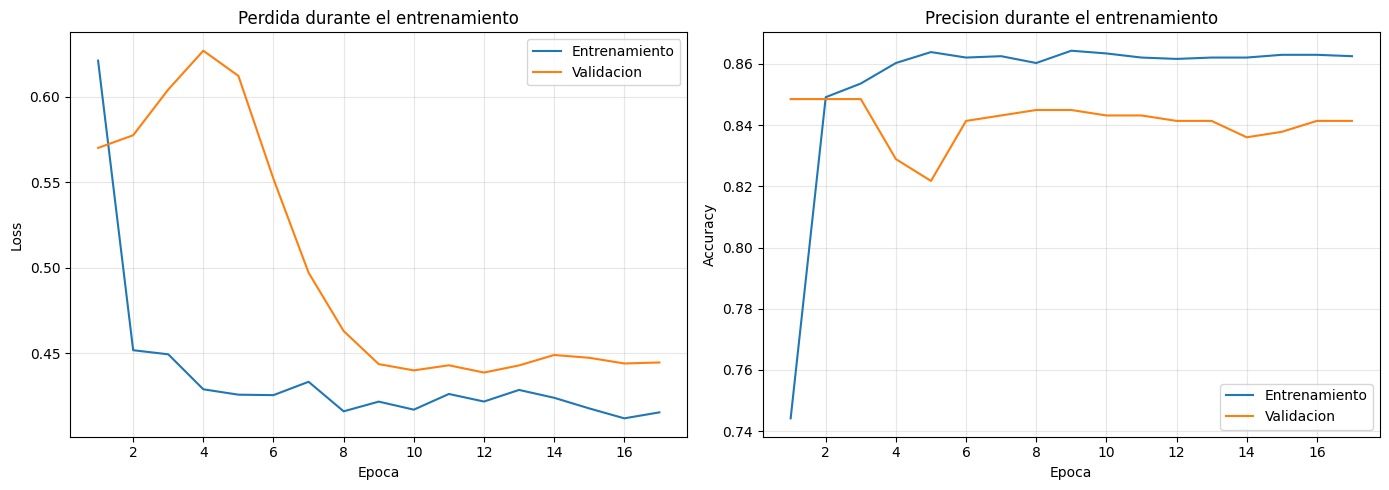

In [5]:
import matplotlib.pyplot as plt

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]
train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
epochs_range = range(1, len(train_loss) + 1)

plt.figure(figsize=(14, 5))

# Grafico de perdida.
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, label="Entrenamiento")
plt.plot(epochs_range, val_loss, label="Validacion")
plt.title("Perdida durante el entrenamiento")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

# Grafico de precision.
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc, label="Entrenamiento")
plt.plot(epochs_range, val_acc, label="Validacion")
plt.title("Precision durante el entrenamiento")
plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## CELDA 6: Metricas de clasificacion por clase

Se calcula la matriz de confusion y las metricas `precision`, `recall` y `F1-score` para cada clase: `seguro` e `inseguro`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

# Asegura que las predicciones queden alineadas con validation_generator.classes.
validation_generator.reset()

y_true = validation_generator.classes
y_pred_proba = model.predict(validation_generator)

class_names_by_index = {
    index: class_name
    for class_name, index in validation_generator.class_indices.items()
}
target_names = [class_names_by_index[index] for index in range(len(class_names_by_index))]
labels = list(range(len(target_names)))

# Umbral mas permisivo para clasificar como seguro.
# Si subes este valor, el modelo sera mas estricto con seguro.
# Si bajas este valor, el modelo clasificara mas imagenes como seguro.
SAFE_CLASSIFICATION_THRESHOLD = 0.40
safe_index = validation_generator.class_indices["seguro"]
unsafe_index = validation_generator.class_indices["inseguro"]
y_pred = np.where(y_pred_proba[:, safe_index] >= SAFE_CLASSIFICATION_THRESHOLD, safe_index, unsafe_index)

print(f"Umbral usado para clasificar como seguro: {SAFE_CLASSIFICATION_THRESHOLD}")

threshold_rows = []
for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    threshold_pred = np.where(y_pred_proba[:, safe_index] >= threshold, safe_index, unsafe_index)
    threshold_precision, threshold_recall, threshold_f1, _ = precision_recall_fscore_support(
        y_true,
        threshold_pred,
        labels=[safe_index],
        zero_division=0,
    )
    threshold_rows.append(
        {
            "umbral_seguro": threshold,
            "precision_seguro": threshold_precision[0],
            "recall_seguro": threshold_recall[0],
            "f1_seguro": threshold_f1[0],
        }
    )

print("Comparacion de metricas para la clase seguro por umbral:")
display(pd.DataFrame(threshold_rows))

cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_df = pd.DataFrame(
    cm,
    index=[f"Real: {name}" for name in target_names],
    columns=[f"Predicho: {name}" for name in target_names],
)

print("Matriz de confusion:")
display(cm_df)

precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=labels,
    zero_division=0,
)

metrics_df = pd.DataFrame(
    {
        "clase": target_names,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "support": support,
    }
)

print("Metricas por clase:")
display(metrics_df)

print("Reporte de clasificacion:")
print(classification_report(y_true, y_pred, labels=labels, target_names=target_names, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Matriz de confusion")
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")
ax.set_xticks(np.arange(len(target_names)))
ax.set_yticks(np.arange(len(target_names)))
ax.set_xticklabels(target_names)
ax.set_yticklabels(target_names)

for row in range(cm.shape[0]):
    for col in range(cm.shape[1]):
        ax.text(col, row, cm[row, col], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()